# Seed Node Identification in Erdős-Rényi Graphs

**Algorithms benchmarked:**
- **BP** — Belief Propagation with EM prior estimation
- **NetFill** — Graph-diffusion baseline
- **ILP** — Integer Linear Programming (MAP estimation)

Run every cell top-to-bottom. Results are saved to CSV and visualised at the end.

## 0. Setup (Google Colab only)

**Skip this cell if running locally.**

Upload the project folder to Colab, then run the cell below:

In [1]:
# ── Google Colab Setup ──────────────────────────────────────────────────────
# Option A: mount Google Drive (recommended)
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/seed_nodes_er_graph')  # adjust path

# Option B: upload a zip, then unzip
# from google.colab import files
# files.upload()                                          # upload the .zip
# !unzip seed_nodes_er_graph.zip -d /content/
# import os
# os.chdir('/content/seed_nodes_er_graph')

# Install dependencies
!pip install -q pyscipopt networkx torch scipy numpy pandas matplotlib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports

In [2]:
import pandas as pd
import torch

from run_experiments import run_benchmark, save_raw_data_to_csv
from utils.plotting import plot_bar_chart, plot_horizontal_runtime_chart

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Experiment Parameters

Edit the values below to configure the benchmark.

In [3]:
# ── Experiment configuration ─────────────────────────────────────────────────
N          = 7000    # number of nodes in the ER graph
NUM_SEEDS  = 100     # true number of seed nodes
BETA       = 0.25   # SI infection probability
P_NOISE    = 0.1    # observation noise probability
AVG_DEGREE = 7     # average node degree
NUM_RUNS   = 1      # number of independent trials

CSV_FILE   = f'results_N{N}_K{NUM_SEEDS}_p{P_NOISE}.csv'
ALGORITHMS = ('NetFill', 'BP', 'ILP')

print('Parameters set ✅')

Parameters set ✅


## 3. Run Benchmark

In [4]:
raw_data = run_benchmark(
    N=N, NUM_SEEDS=NUM_SEEDS, BETA=BETA, P_NOISE=P_NOISE,
    AVG_DEGREE=AVG_DEGREE, num_runs=NUM_RUNS,
    csv_filename=CSV_FILE, algorithms=ALGORITHMS
)
print('\n✅ Benchmark complete!')


  RUN 1 / 1
🚀 BENCHMARK STARTING...
   Device: cpu
   Nodes: 7000 | Seeds: 100 | Beta: 0.25 | Noise: 0.1
   Avg Degree: 7
------------------------------------------------------------
1️⃣  OK Generating Data (ER Graph + SI Simulation)...
 Data ready. Observed infected nodes: 259.0
------------------------------------------------------------

2️⃣  Running Algorithm: BELIEF PROPAGATION (BP)...
--- 🔄 Starting EM for Prior Estimation --- Init rho: 0.00693
   --> EM Converged at Iter 4. Optimal Rho = 0.01441
🚀 Starting BP  on cpu...
🔹  Running Final BP with Prior =0.01...
   [Decision] Selected 95 seeds.
>>> Total Seeds Found: 95
   >> Optimal Prior: 0.014410664327442646
   >> BP Finished in 0.4691s

3️⃣  Running Algorithm: NETFILL...
Iter 0: Old C size = 1435, New C size = 0
Iter 1: Old C size = 0, New C size = 0
Iter 2: Old C size = 0, New C size = 0
   >> NETFILL Finished in 0.9752s

4️⃣  Running Algorithm: ILP (MAP Estimation)...
   [ILP Info] Estimated seed sparsity (pi): 0.01493
   >>

## 4. Load & Summarise Results

In [5]:
df = pd.read_csv(CSV_FILE)
mean_df = df.groupby('Algorithm')[['Precision', 'Recall', 'F1-Score', 'Runtime']].mean()
print('Average results across runs:')
display(mean_df.round(4))

mean_metrics_dict = mean_df[['Precision', 'Recall', 'F1-Score']].to_dict('index')
mean_runtime_dict = mean_df['Runtime'].to_dict()

Average results across runs:


,Precision,Recall,F1-Score,Runtime
Algorithm,,,,
BP,0.8526,0.81,0.8308,0.4691
ILP,0.8526,0.81,0.8308,50.4784
NetFill,1.0000,0.01,0.0198,0.9752


## 5. Visualise: Performance Metrics

📸 Đã lưu biểu đồ tại: /content/drive/MyDrive/plots/fig_performance.eps


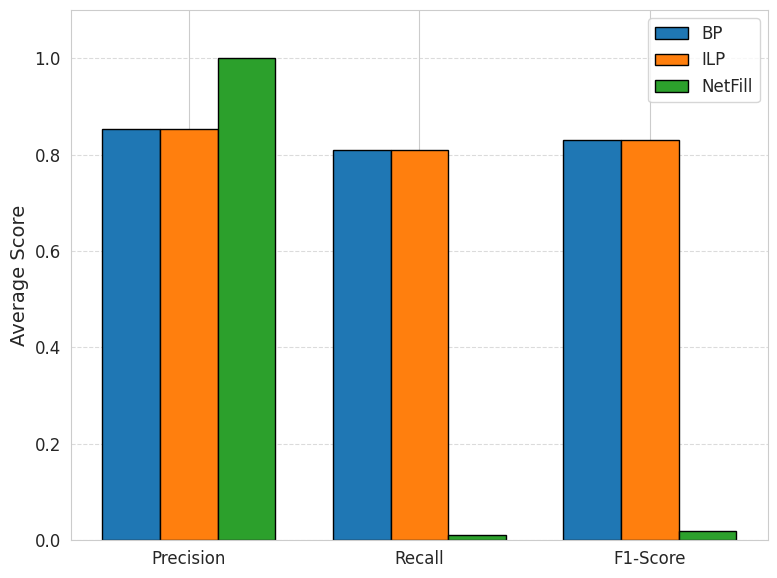

In [6]:
plot_bar_chart(
    metrics_dict=mean_metrics_dict,
    title=f'Average Performance over {NUM_RUNS} runs\n(N={N}, K={NUM_SEEDS}, Beta={BETA}, p={P_NOISE})',
    ylabel='Average Score',
    filename='fig_performance'
)

## 6. Visualise: Runtime Comparison

📸 Đã lưu biểu đồ tại: /content/drive/MyDrive/plots/fig_runtime.eps


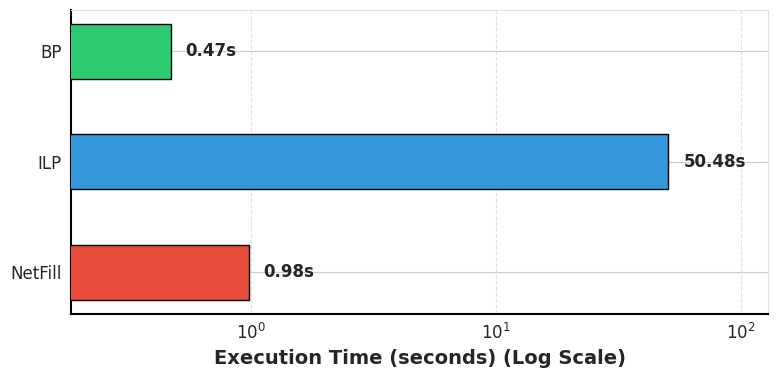

In [7]:
plot_horizontal_runtime_chart(
    runtime_dict=mean_runtime_dict,
    xlabel='Execution Time (seconds)',
    filename='fig_runtime'
)